# Crab Age Prediction

## Introduction

**Dataset:** https://www.kaggle.com/datasets/sidhus/crab-age-prediction

For a commercial crab farmer, knowing the right age of the crab helps them decide if and when to harvest the crabs. Beyond a certain age, there is negligible growth in a crab's physical characteristics and hence, it is important to time the harvesting to reduce cost and increase profit.

Our task is to build a regression model to estimate the age of crabs (in months) using their physical characteristics.

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/CrabAgePrediction.csv")
df.head()

,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
0,F,1.4375,1.1750,0.4125,24.635715,12.332033,5.584852,6.747181,9
1,M,0.8875,0.6500,0.2125,5.400580,2.296310,1.374951,1.559222,6
2,I,1.0375,0.7750,0.2500,7.952035,3.231843,1.601747,2.764076,6
3,F,1.1750,0.8875,0.2500,13.480187,4.748541,2.282135,5.244657,10
4,I,0.8875,0.6625,0.2125,6.903103,3.458639,1.488349,1.700970,6


## Checking for Duplicates and Missing Values

In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.isna().sum()

Sex               0
Length            0
Diameter          0
Height            0
Weight            0
Shucked Weight    0
Viscera Weight    0
Shell Weight      0
Age               0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3893 entries, 0 to 3892
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             3893 non-null   str    
 1   Length          3893 non-null   float64
 2   Diameter        3893 non-null   float64
 3   Height          3893 non-null   float64
 4   Weight          3893 non-null   float64
 5   Shucked Weight  3893 non-null   float64
 6   Viscera Weight  3893 non-null   float64
 7   Shell Weight    3893 non-null   float64
 8   Age             3893 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 273.9 KB


Our dataset is already clean.

## Exploratory Data Analysis

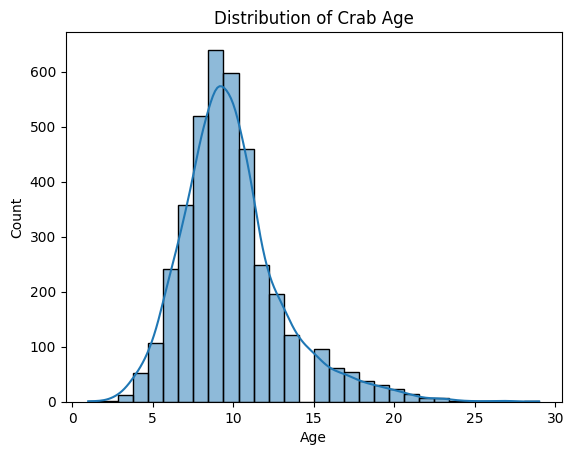

In [6]:
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Distribution of Crab Age")
plt.show()

Most crabs in the dataset fall between roughly 7 and 12 months old, with the distribution tapering off for younger and much older crabs. The distribution is slightly right skewed, meaning there are a small number of noticeably older crabs pulling the tail out to the right.

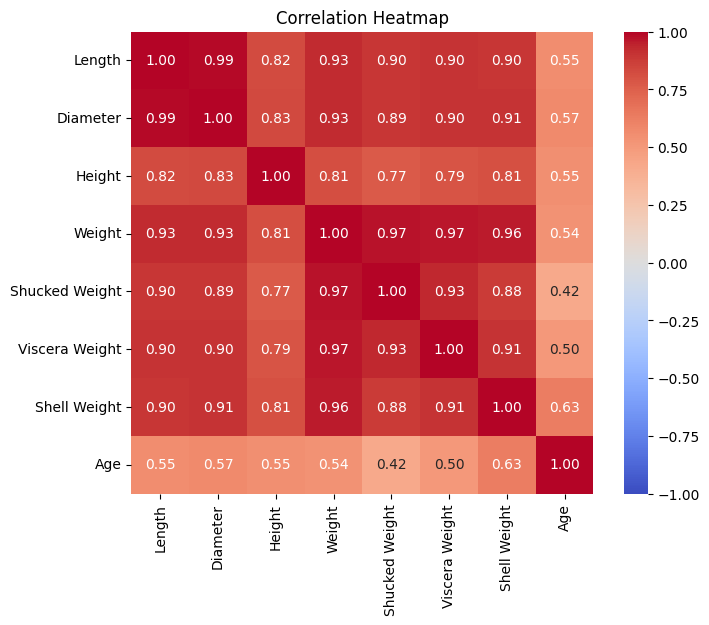

In [7]:
plt.figure(figsize=(8, 6))
correlations = df.corr(numeric_only=True)
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Heatmap")
plt.show()

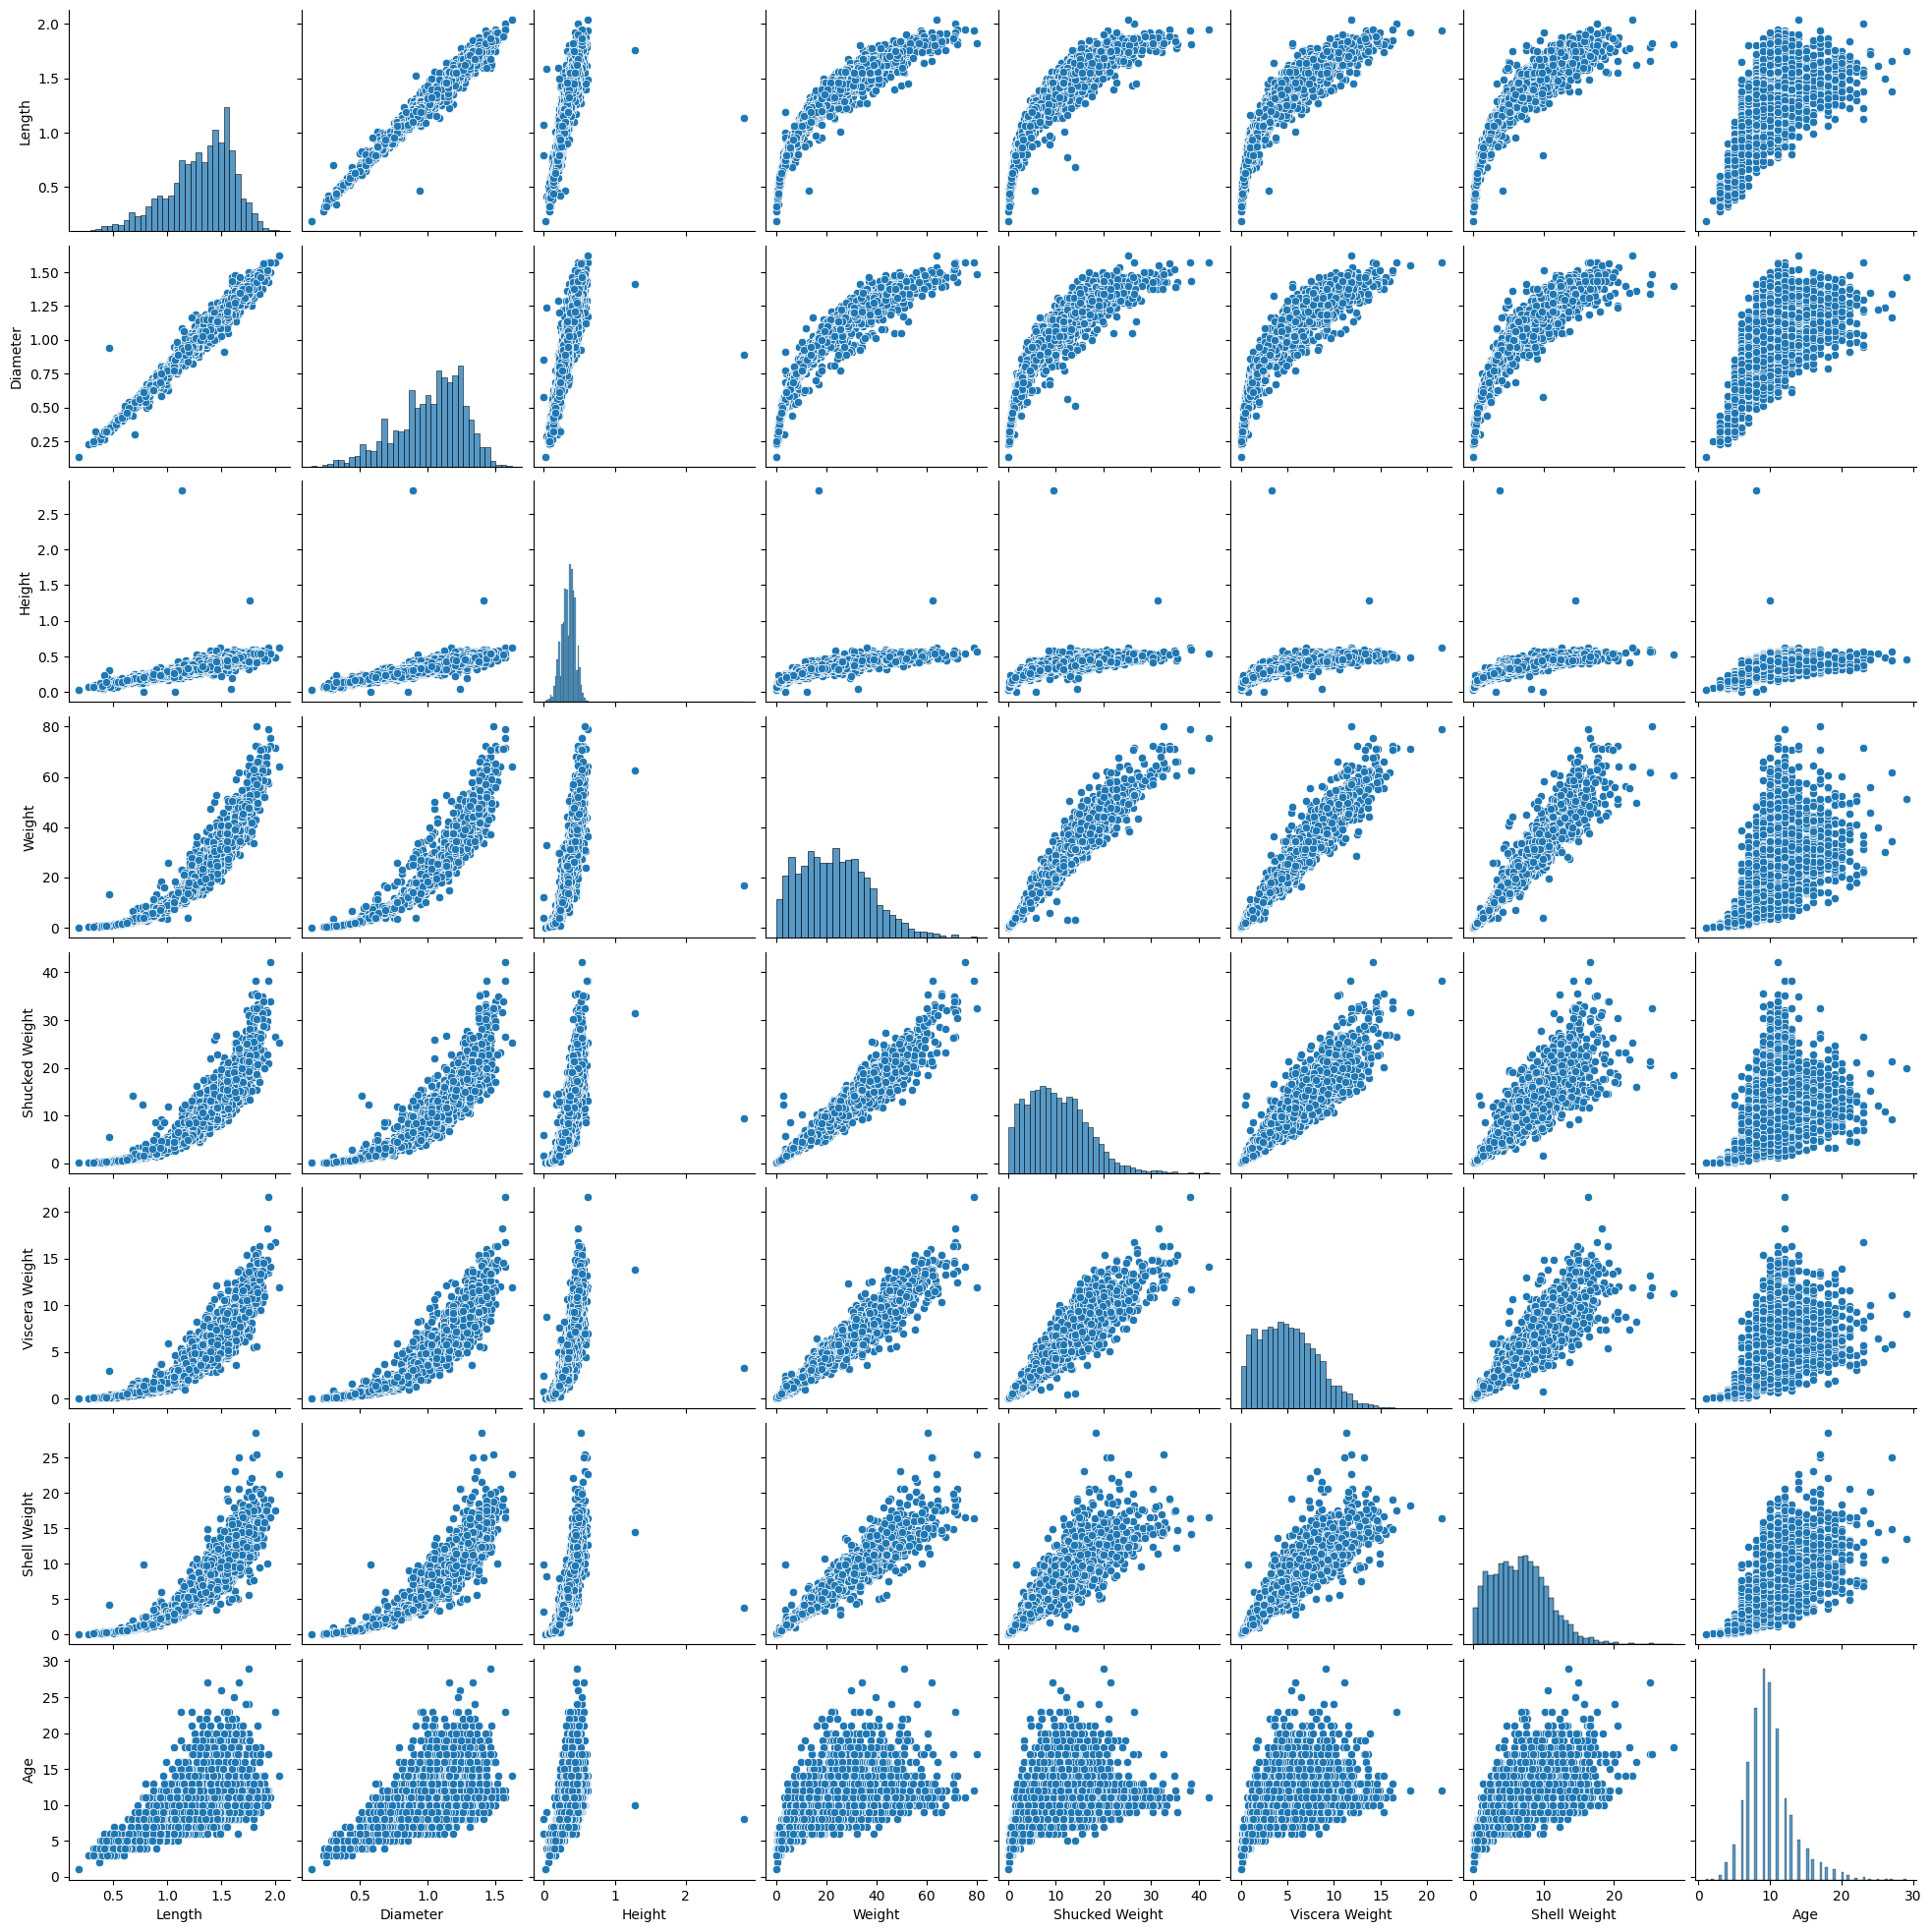

In [8]:
sns.pairplot(data=df)
plt.show()

All of the physical measurements are strongly positively correlated with each other, which makes sense since a bigger crab tends to be longer, wider, taller and heavier all at once.

## Encoding Categorical Variables

The `Sex` column contains three categories: *Male*, *Female* and *Indeterminate*. Since it is a nominal categorical variable, we will apply one-hot encoding to convert it into numerical features.

In [9]:
df = pd.get_dummies(df)

df.head()

,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age,Sex_F,Sex_I,Sex_M
0,1.4375,1.1750,0.4125,24.635715,12.332033,5.584852,6.747181,9,True,False,False
1,0.8875,0.6500,0.2125,5.400580,2.296310,1.374951,1.559222,6,False,False,True
2,1.0375,0.7750,0.2500,7.952035,3.231843,1.601747,2.764076,6,False,True,False
3,1.1750,0.8875,0.2500,13.480187,4.748541,2.282135,5.244657,10,True,False,False
4,0.8875,0.6625,0.2125,6.903103,3.458639,1.488349,1.700970,6,False,True,False


## Getting our Features and Target

Our target variable is `Age`. We will separate the features and the target variable.

In [10]:
X = df.drop(columns=["Age"])
y = df["Age"]

## Splitting into Train and Test Sets

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Just like before, there is no need to scale the numerical features or the target variable. Tree-based regression models are not sensitive to feature scaling.

## Training and Evaluating a Base Model

We will use the XGBoost Regressor, with the `random_state` set to 42, as our baseline model.

In [12]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)

xgb.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [13]:
from sklearn.metrics import mean_absolute_error

In [14]:
y_pred = xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae}")

MAE: 1.5965298414230347


This means the models's predictions are off by an average of 1.5 months which is good but there is still room for improvement. Let us try hyperparameter tuning to see if we can improve the model's performance.

## Hyperparameter Tuning

A **hyperparameter** is a parameter that can be set in order to define any configurable part of a model's learning process.  It is a parameter whose value is used to control the learning process, and must be configured before the process starts.

Therefore, **hyperparameter tuning** is the process of selecting the optimal values for a machine learning model's hyperparameters. Hyperparameter tuning determines the set of hyperparameters that yields an optimal model which minimizes a predefined loss function on a given data set.

In this notebook, the approach we will be taking is **Grid Search**. This is simply an exhaustive searching through a manually specified subset of the hyperparameter space of a learning algorithm. A grid search algorithm must be guided by some performance metric, typically measured by cross-validation on the training set or evaluation on a hold-out validation set. In other words, grid search works using the steps below:

- Create a grid of potential values for each hyperparameter.
- Train the model for every combination in the grid.
- Evaluate each model using cross-validation.
- Select the combination that gives the highest score.

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200], # Number of trees in the ensemble
    "max_depth": [3, 5, 7], # Maximum depth of the trees
    "learning_rate": [0.01, 0.1, 0.2], # Step size shrinkage
    "subsample": [0.8, 1.0], # Fraction of samples used to fit each tree
    "colsample_bytree": [0.8, 1.0] # Fraction of features used to fit each tree
}

xgb = XGBRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=xgb, 
    param_grid=param_grid, 
    cv=5, # 5 fold cross-validation
    scoring="neg_mean_absolute_error", # Use MAE as the scoring metric
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for 

Let us see the best parameters.

In [16]:
print("Best parameters found: ", grid_search.best_params_)

Best parameters found:  {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 1.0}


Now we will take the best model found by the grid search and evaluate it on the test set, so we can compare it directly against our base model.

In [17]:
best_rf = grid_search.best_estimator_

In [18]:
y_pred = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae}")

MAE: 1.4916433095932007


Comparing this to our base model shows that tuning actually helped. A lower MAE indicates an improvement. It is worth noting that hyperparameter tuning does not always produce a dramatic improvement, especially when the base model's defaults are already reasonably well suited to the data, but it is still good practice to check.

## Assignment

**Dataset:** https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset

Financial institutions receive numerous loan applications every day. Evaluating each application manually can be time-consuming and prone to inconsistencies. Machine learning provides an efficient approach to automating this process by identifying patterns in historical loan application data.

In this assignment, you will build a binary classification model to predict whether a loan application will be approved or rejected based on the applicant's demographic, financial, and credit-related information contained in the dataset.